In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


## Handling Missing Values

- **deck**: 75%+ missing hai, isliye pura column drop kar rahe hain.
- **age**: ~20% missing hai. Har passenger class (pclass) ke median age se fill kar rahe hain, kyunke age survival ke liye important hai aur classes ke beech age alag distribute hai.
- **embarked**: sirf 2 rows missing hain, mode (sab se common value) se fill kar rahe hain.

In [5]:
df_clean = df.copy()

# deck drop
df_clean = df_clean.drop(columns=["deck"])

# age fill by pclass median
df_clean["age"] = df_clean.groupby("pclass")["age"].transform(
    lambda x: x.fillna(x.median())
)

# embarked fill by mode
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
df_clean["embark_town"] = df_clean["embark_town"].fillna(df_clean["embark_town"].mode()[0])

df_clean.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


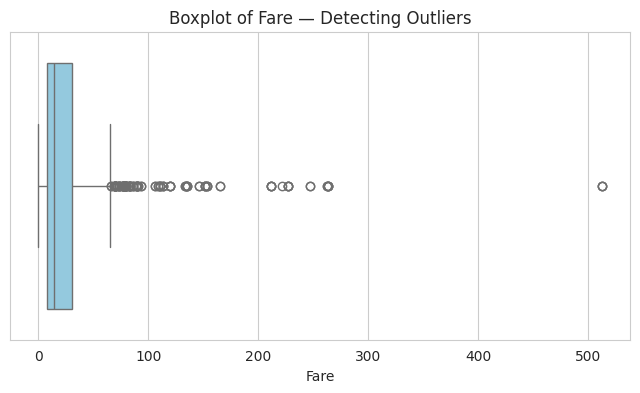

Number of outliers in 'fare': 116


In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["fare"], color="skyblue")
plt.title("Boxplot of Fare — Detecting Outliers")
plt.xlabel("Fare")
plt.show()

Q1 = df_clean["fare"].quantile(0.25)
Q3 = df_clean["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["fare"] < lower_bound) | (df_clean["fare"] > upper_bound)]
print(f"Number of outliers in 'fare': {len(outliers)}")


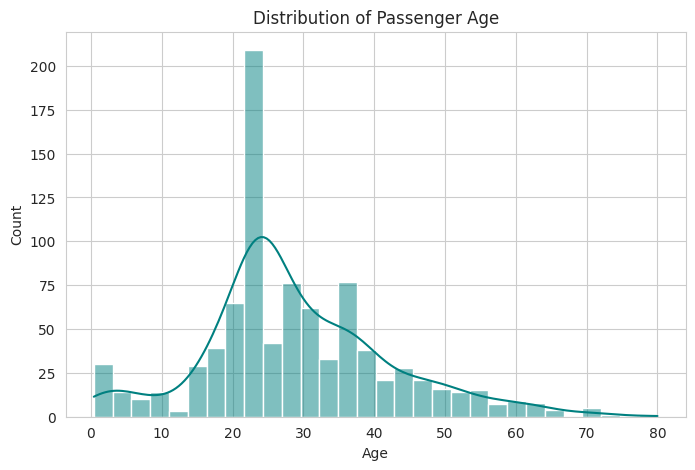

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], bins=30, kde=True, color="teal")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_3270/1642804216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pclass", y="fare", data=df_clean, palette="Set2")


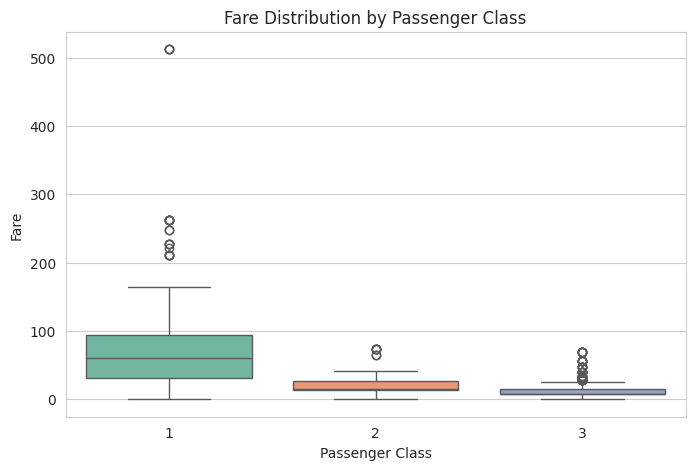

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="pclass", y="fare", data=df_clean, palette="Set2")
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()


/tmp/ipykernel_3270/3912969565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df_clean, palette="pastel", errorbar=None)


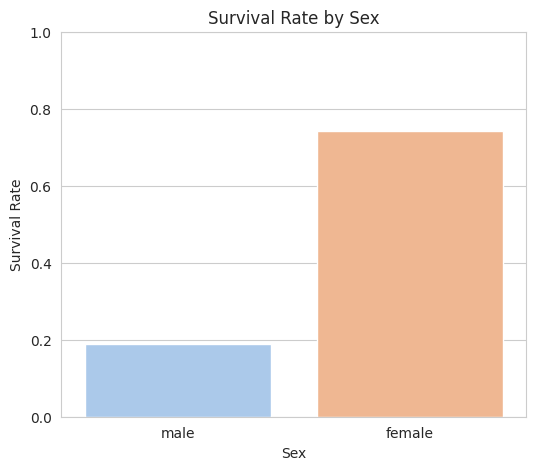

In [9]:
plt.figure(figsize=(6, 5))
sns.barplot(x="sex", y="survived", data=df_clean, palette="pastel", errorbar=None)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

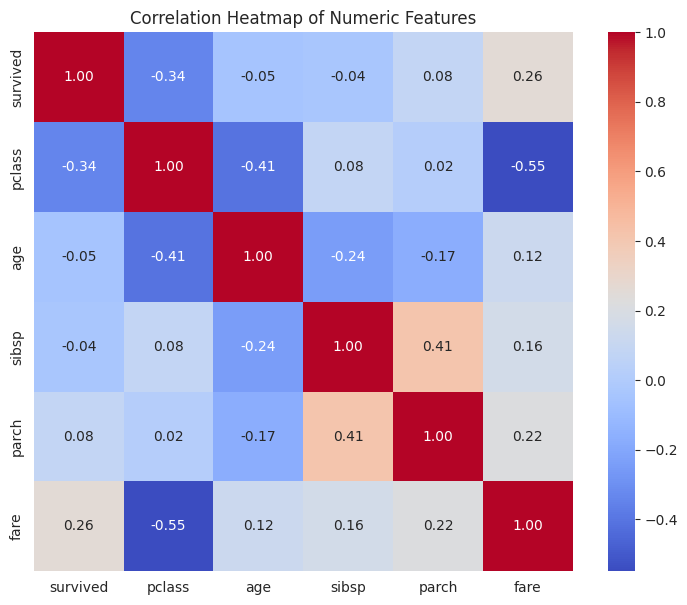

In [10]:
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Which feature affects survival the most, and why?

**Sex** sab se zyada survival ko affect karta hai — bar chart mein saaf dikh raha hai ke females ki survival rate males se kaafi zyada thi ("women and children first" policy ki wajah se). Iske baad **pclass** aur **fare** bhi important hain — first class passengers ko lifeboats tak pehle access mila. Correlation heatmap bhi ye confirm karta hai ke sex aur pclass, survival ke saath sab se zyada correlated hain age ke muqable mein.